In [1]:
import os
import time
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, models, transforms
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score
from torch.utils.data import ConcatDataset
from sklearn.model_selection import train_test_split

# 记录开始时间
start_time = time.time()

# 定义超参数
batch_size = 64
learning_rate = 0.001
num_epochs = 100

data_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 加载数据集
data_dir = 'C:/Users/WHS/Desktop/SVM-Image-Classification-master/images4'
image_datasets = datasets.ImageFolder(data_dir, data_transforms)

# 划分训练集和测试集
train_data, test_data = train_test_split(image_datasets, test_size=0.3, random_state=42)

dataloaders = {'train':torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True, num_workers=4),
               'val':torch.utils.data.DataLoader(test_data, batch_size=64, shuffle=False, num_workers=4)}
dataset_sizes = {'train': len(train_data),'val': len(test_data)}

In [2]:
model = models.shufflenet_v2_x1_0(pretrained=True)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 4)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = model.to(device)


# 定义损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), 
                      lr=learning_rate, momentum=0.9)

# 训练模型
result = {
          "acu_train": [],
          "acu_test": [],
          "loss_train":[],
          "recall": []
          }
for epoch in range(num_epochs):
    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()
        else:
            model.eval()

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloaders[phase]:
            
#             print(phase,'epoch',":",epoch,'num_imputs',inputs.size())
#             tensor = inputs[0].to(torch.float32).cpu()
#             print(labels[0])
#             # 将张量转换为图像并显示
#             plt.imshow(tensor.permute(1, 2, 0))
#             plt.show()
            
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc = running_corrects.double() / dataset_sizes[phase]
        
        if phase=='train':
            result["acu_train"].append('{:.4f}'.format(epoch_acc))
            result["loss_train"].append('{:.4f}'.format(epoch_loss))
        elif phase=='val':
            result["acu_test"].append('{:.4f}'.format(epoch_acc))
            recall = recall_score(labels.data.detach().cpu().numpy(), preds.detach().cpu().numpy(), average="macro")
            result["recall"].append(recall)

        print('epoch: {}, {} Loss: {:.4f} Acc: {:.4f}'.format(epoch, phase, epoch_loss, epoch_acc))
        with open('C:/Users/WHS/Desktop/Dual-ResNet18-SVM/result/result_file_ShuffleNet.txt', "a") as file:
            file.write('epoch: {}, {} Loss: {:.4f} Acc: {:.4f}\n'.format(epoch, phase, epoch_loss, epoch_acc))

epoch: 0, train Loss: 1.3837 Acc: 0.3275
epoch: 0, val Loss: 1.3879 Acc: 0.2342
epoch: 1, train Loss: 1.3833 Acc: 0.3411
epoch: 1, val Loss: 1.3858 Acc: 0.2432
epoch: 2, train Loss: 1.3825 Acc: 0.3527
epoch: 2, val Loss: 1.3846 Acc: 0.2387
epoch: 3, train Loss: 1.3817 Acc: 0.3391
epoch: 3, val Loss: 1.3845 Acc: 0.2252
epoch: 4, train Loss: 1.3806 Acc: 0.3333
epoch: 4, val Loss: 1.3846 Acc: 0.2387
epoch: 5, train Loss: 1.3799 Acc: 0.3430
epoch: 5, val Loss: 1.3841 Acc: 0.2432
epoch: 6, train Loss: 1.3791 Acc: 0.3450
epoch: 6, val Loss: 1.3825 Acc: 0.2658
epoch: 7, train Loss: 1.3782 Acc: 0.3566
epoch: 7, val Loss: 1.3813 Acc: 0.2793
epoch: 8, train Loss: 1.3774 Acc: 0.3857
epoch: 8, val Loss: 1.3808 Acc: 0.2838
epoch: 9, train Loss: 1.3769 Acc: 0.4109
epoch: 9, val Loss: 1.3806 Acc: 0.3153
epoch: 10, train Loss: 1.3761 Acc: 0.4244
epoch: 10, val Loss: 1.3800 Acc: 0.3423
epoch: 11, train Loss: 1.3754 Acc: 0.4554
epoch: 11, val Loss: 1.3793 Acc: 0.3784
epoch: 12, train Loss: 1.3745 Acc: 0

In [3]:
# 记录结束时间
end_time = time.time()

# 计算算法运行时间
execution_time = end_time - start_time
print(execution_time)

322.9062361717224


In [4]:
torch.save(model.state_dict(), 'ShuffleNet.pth')

In [1]:
import os
import time
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, models, transforms
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score
from torch.utils.data import ConcatDataset
from sklearn.model_selection import train_test_split

data_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
# 加载数据集
data_dir = 'C:/Users/WHS/Desktop/SVM-Image-Classification-master/images3'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms) for x in ['train', 'val']}
test_loader = torch.utils.data.DataLoader(image_datasets['val'], batch_size=64, shuffle=True, num_workers=4)

model = models.shufflenet_v2_x1_0()
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 4)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# 加载之前保存的模型参数
model.load_state_dict(torch.load('ShuffleNet.pth'))

start_time = time.time()
for inputs, labels in test_loader:    
    inputs = inputs.to(device)
    labels = labels.to(device)
    outputs = model(inputs)
    _, preds = torch.max(outputs, 1)
    print(labels,preds)
    break
# 记录结束时间
end_time = time.time()

# 计算算法运行时间
execution_time = end_time - start_time
print(execution_time/len(labels))

tensor([0, 3, 3, 3, 1, 2, 1, 2, 1, 0, 3, 0, 2, 2, 1, 2, 3, 3, 0, 1, 1, 2, 3, 2,
        1, 0, 1, 3, 3, 3, 1, 0, 1, 3, 3, 2, 3, 0, 1, 0, 1, 2, 3, 1, 0, 2, 3, 0,
        3, 0, 1, 1, 2, 0, 0, 2, 3, 3, 3, 0, 3, 3, 1, 0], device='cuda:0') tensor([0, 3, 3, 3, 2, 2, 1, 2, 1, 0, 3, 2, 2, 2, 3, 2, 3, 3, 3, 3, 1, 2, 1, 2,
        1, 3, 2, 3, 3, 3, 1, 2, 2, 3, 2, 2, 1, 1, 2, 2, 1, 2, 3, 3, 2, 2, 2, 3,
        3, 1, 2, 1, 2, 3, 2, 2, 3, 1, 3, 0, 3, 3, 1, 3], device='cuda:0')
0.05398093909025192


In [2]:
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


"""Use this method directly - """
import itertools
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    matplotlib.rcParams['font.size'] = 18
    matplotlib.rcParams['font.family'] = 'Times New Roman'
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    fig = plt.gcf()
    fig.set_size_inches(5, 4)
    fig.subplots_adjust(left=0.2, bottom=0.2)
    fig.savefig('ShuffleNet_con.png', dpi=300)
    plt.tight_layout()

In [3]:
labels = labels.cpu()
preds = preds.cpu()
cnf_matrix = confusion_matrix(labels.data, preds)
print(cnf_matrix)

[[ 3  2  5  5]
 [ 0  8  5  3]
 [ 0  0 12  0]
 [ 0  3  2 16]]


Normalized confusion matrix
[[0.2        0.13333333 0.33333333 0.33333333]
 [0.         0.5        0.3125     0.1875    ]
 [0.         0.         1.         0.        ]
 [0.         0.14285714 0.0952381  0.76190476]]


<ipython-input-2-014ab2c3dccc>:46: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations. 
  plt.tight_layout()


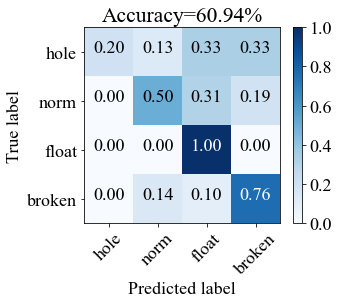

In [4]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(labels.data, preds)
plt.figure()
plot_confusion_matrix(cnf_matrix, ['hole','norm','float','broken'],normalize=True,title='Accuracy={:.2f}%'.format(accuracy*100),cmap=plt.cm.Blues)